# H2: Fairness and Moral Disengagement

**Hypothesis**: Lower perceived fairness of the hiring process is associated with greater willingness to cheat, on the grounds that candidates who view the process as unjust face a lower moral cost to dishonest conduct (Bandura, 1999).

**Relevant Survey Items:**
- **Optional Question 1 (Q21)**: Overall fairness assessment of the modern job interview process
- **Question 3 (Q3_1–Q3_6)**: Acceptability ratings for six specific cheating behaviors
- **Question 5b (Q6/open-ended)**: Open-ended elaboration on why candidates cheat
- **Question 12 (Q13a)**: Willingness to use unauthorized assistance under high peer cheating conditions

---

## 1. Setup and Data Loading

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetics ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
HUMAN_COLOR  = '#2563EB'   # blue
AGENT_COLOR  = '#DC2626'   # red
NEUTRAL_COLOR = '#6B7280'  # grey

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [ ]:
# ── Load data ──────────────────────────────────────────────────────────────────
raw = pd.read_excel("Data Files\\Human Survey Responses.xlsx", header=0)

df = raw.iloc[1:].copy().reset_index(drop=True)

# Rename columns to short, meaningful labels using the survey map below
col_map = {
    'Consent Page'            : 'consent',
    'Question 1_1'            : 'q1_smartphone',
    'Question 1_2'            : 'q1_music',
    'Question 1_3'            : 'q1_coffee',
    'Question 1_4'            : 'q1_skydive',
    'Question 1_5'            : 'q1_helicopter',
    'Question 1_6'            : 'q1_pay_interview',
    'Question 1_7'            : 'q1_gym',
    'Question 1_8'            : 'q1_cheat_partner',
    'Question 1_9'            : 'q1_exam_cheat',
    'Question 1_10'           : 'q1_ai_interview_answers',
    'Question 1_11'           : 'q1_ai_practice',
    'Question 1_12'           : 'q1_essay_ghost',
    'Question 1_13'           : 'q1_hidden_assist',
    'Question 1_14'           : 'q1_perform_music',
    'Question 2_1'            : 'q2_pct_cheated',
    'Question 3_1'            : 'q3_ai_during',
    'Question 3_2'            : 'q3_search_engine',
    'Question 3_3'            : 'q3_questions_beforehand',
    'Question 3_4'            : 'q3_live_assist',
    'Question 3_5'            : 'q3_handwritten_notes',
    'Question 3_6'            : 'q3_ai_notes',
    'Question 4'              : 'q4_attention_color',
    'Question 5a_1'           : 'q5a_desperation',
    'Question 5a_2'           : 'q5a_competition',
    'Question 5a_3'           : 'q5a_confidence',
    'Question 5a_4'           : 'q5a_unfair_process',
    'Question 5a_5'           : 'q5a_online_risk',
    'Question 5a_6'           : 'q5a_cultural_norms',
    'Question 5a_7'           : 'q5a_lack_guidance',
    'Question 5a_8'           : 'q5a_bandwagon',
    'Question 6'              : 'q6_open_why_cheat',
    'Question 7'              : 'q7_attention_chicago_il',
    'Question 8'              : 'q8_attention_chicago_ny',
    'Question 9'              : 'q9_know_ai_hw',
    'Question 10'             : 'q10_know_ai_interview_adv',
    'Question 11'             : 'q11_know_search_live',
    'Question 12'             : 'q12_know_ai_live',
    'Q37'                     : 'code_id_raw',
    'Question 13a'            : 'q13a_willingness_high_peer',
    'Question 13b'            : 'q13b_acceptable_high_peer',
    'Question 14a'            : 'q14a_willingness_no_peer',
    'Question 14b'            : 'q14b_acceptable_no_peer',
    'Question 15'             : 'q15_year',
    'Question 16'             : 'q16_field',
    'Question 16_21_TEXT'     : 'q16_field_other',
    'Question 17'             : 'q17_industry',
    'Question 17_19_TEXT'     : 'q17_industry_other',
    'Question 18'             : 'q18_employment',
    'Question 19'             : 'q19_num_interviews',
    'Question 20'             : 'q20_interview_format',
    'Feedback Question'       : 'feedback',
    'Raffle Question'         : 'raffle',
    'Branching Question'      : 'branching',
    'Optional Question 1'     : 'q21_fairness',
    'Optional Question 2'     : 'q22_report_peer',
    'Optional Question 3'     : 'q23_detect_confidence',
    'Optional Question 4'     : 'q24_enforce_confidence',
    'Optional Question 5'     : 'q25_consequence',
    'Optional Question 6'     : 'q26_ai_skill_confidence',
    'HAVE_SYMBOL'             : 'have_symbol',
    'HAVE_NOT_SYMBOL'         : 'have_not_symbol',
    'CODE_ID'                 : 'code_id',
}
df.rename(columns=col_map, inplace=True)

print(f'Dataset: {len(df)} human respondents, {len(df.columns)} columns')
df.head(242)

Dataset: 249 human respondents, 69 columns


,UserLanguage,consent,q1_smartphone,q1_music,q1_coffee,q1_skydive,q1_helicopter,q1_pay_interview,q1_gym,q1_cheat_partner,...,q25_consequence,q26_ai_skill_confidence,have_symbol,have_not_symbol,code_id,Q_AmbiguousTextPresent,Q_AmbiguousTextQuestions,Q_StraightliningCount,Q_StraightliningPercentage,Q_StraightliningQuestions
0,EN,I agree to participate in this research study.,Very Common,Very Common,Very Common,Uncommon,Very Rare,Very Rare,NaN,Rare,...,NaN,NaN,ODD NUMBER,UPPERCASE LETTER,4,0,NaN,0,0,NaN
1,EN,I agree to participate in this research study.,Very Common,NaN,Very Common,NaN,Very Rare,Very Rare,Common,Uncommon,...,NaN,NaN,UPPERCASE LETTER,COLOR,1,0,NaN,0,0,NaN
2,EN,I agree to participate in this research study.,NaN,Very Common,Very Common,Rare,Very Rare,NaN,NaN,Uncommon,...,Automatic disqualification from the current ap...,Not confident at all,UPPERCASE LETTER,COLOR,1,0,NaN,1,0.333333,QID11
3,EN,I agree to participate in this research study.,NaN,NaN,Very Common,Uncommon,Very Rare,Rare,Common,Rare,...,Permanent ban from applying to the company.,Slightly confident,UPPERCASE LETTER,COLOR,1,0,NaN,0,0,NaN
4,EN,I agree to participate in this research study.,Very Common,Common,Very Common,Very Rare,Very Rare,NaN,Common,Very Rare,...,NaN,NaN,LOWERCASE LETTER,EVEN NUMBER,5,0,NaN,1,0.333333,QID11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,EN,I agree to participate in this research study.,NaN,Very Common,Common,NaN,Rare,Uncommon,Common,Common,...,Automatic disqualification from the current ap...,Not confident at all,COLOR,LOWERCASE LETTER,2,0,NaN,0,0,NaN
238,EN,I agree to participate in this research study.,NaN,NaN,Uncommon,NaN,Very Rare,Very Rare,Uncommon,Very Rare,...,Automatic disqualification from the current ap...,Moderately confident,COLOR,LOWERCASE LETTER,2,0,NaN,0,0,NaN
239,EN,I agree to participate in this research study.,Very Common,Very Common,Very Common,Very Rare,Very Rare,NaN,NaN,Common,...,NaN,NaN,COLOR,LOWERCASE LETTER,2,0,NaN,0,0,NaN
240,EN,I agree to participate in this research study.,NaN,NaN,Very Common,NaN,Very Rare,Rare,Very Common,Rare,...,NaN,NaN,COLOR,LOWERCASE LETTER,2,0,NaN,0,0,NaN


---
## 2. Ordinal Encoding Helpers

All Likert-scale columns are converted to integers so that correlations and
cross-tabulations work correctly. Scales are defined so that **higher = more
permissive / less deterred**.

In [48]:
# ── Fairness scale  (Optional Q1) ─────────────────────────────────────────────
# Higher number → MORE fair
fairness_map = {
    'Extremely unfair'       : 1,
    'Somewhat unfair'        : 2,
    'Neither fair nor unfair': 3,
    'Somewhat fair'          : 4,
    'Extremely fair'         : 5,
}

# ── Acceptability scale (Q3_x) ────────────────────────────────────────────────
# Higher → MORE acceptable
accept_map = {
    'Completely Unacceptable': 1,
    'Somewhat Unacceptable'  : 2,
    'Neutral'                : 3,
    'Somewhat Acceptable'    : 4,
    'Acceptable'             : 5,
}

# ── Willingness scale (Q13, Q14) ──────────────────────────────────────────────
# Higher → MORE willing
willing_map = {
    'Extremely unlikely'         : 1,
    'Somewhat unlikely'          : 2,
    'Neither likely nor unlikely': 3,
    'Somewhat likely'            : 4,
    'Extremely likely'           : 5,
    'Extremely Likely'           : 5,
}

# Apply encodings
df['q21_fairness_n']           = df['q21_fairness'].map(fairness_map)
df['q13a_willingness_high_n']   = df['q13a_willingness_high_peer'].map(willing_map)
df['q14a_willingness_no_n']     = df['q14a_willingness_no_peer'].map(willing_map)

accept_cols = ['q3_ai_during','q3_search_engine','q3_questions_beforehand',
               'q3_live_assist','q3_handwritten_notes','q3_ai_notes']
accept_labels = ['AI During\nInterview','Search Engine\nDuring Interview',
                 'Questions\nBeforehand','Live Assist\nBehind Scenes',
                 'Handwritten\nNotes','AI-Generated\nNotes']

for col in accept_cols:
    df[col + '_n'] = df[col].map(accept_map)

accept_n_cols = [c + '_n' for c in accept_cols]
df['q3_mean_accept'] = df[accept_n_cols].mean(axis=1)

# ── Fairness direction flag ────────────────────────────────────────────────────
# Respondents are coded as "unfair-leaning" if they selected Somewhat or Extremely Unfair
df['unfair_flag'] = df['q21_fairness'].isin(['Somewhat unfair', 'Extremely unfair'])

print('Encoding complete.')
df[['q21_fairness','q21_fairness_n','q13a_willingness_high_peer',
    'q13a_willingness_high_n'] + accept_n_cols].head(242)

Encoding complete.


,q21_fairness,q21_fairness_n,q13a_willingness_high_peer,q13a_willingness_high_n,q3_ai_during_n,q3_search_engine_n,q3_questions_beforehand_n,q3_live_assist_n,q3_handwritten_notes_n,q3_ai_notes_n
0,NaN,NaN,Extremely likely,5,1.0,1.0,2.0,1,1.0,3.0
1,NaN,NaN,Extremely likely,5,4.0,2.0,2.0,2,5.0,5.0
2,Somewhat unfair,2.0,Somewhat likely,4,3.0,3.0,2.0,2,5.0,4.0
3,Somewhat fair,4.0,Somewhat likely,4,1.0,2.0,2.0,1,3.0,2.0
4,NaN,NaN,Extremely unlikely,1,1.0,1.0,3.0,1,2.0,5.0
...,...,...,...,...,...,...,...,...,...,...
237,Somewhat unfair,2.0,Extremely unlikely,1,2.0,4.0,1.0,2,5.0,5.0
238,Somewhat unfair,2.0,Somewhat likely,4,2.0,2.0,5.0,1,5.0,4.0
239,NaN,NaN,Extremely likely,5,5.0,3.0,5.0,1,5.0,5.0
240,NaN,NaN,Neither likely nor unlikely,3,1.0,2.0,3.0,1,5.0,5.0


---
## 3. Fairness Distribution (Q21)

> *"On the fairness question, human respondents were moderately but not strongly skeptical. [X]% rated the process as 'Somewhat Unfair', while [X]% rated it 'Neither Fair nor Unfair' and [X]% 'Somewhat Fair'. Notably few respondents chose either extreme: only [X]% reported the process as 'Extremely Unfair' and [X]% as 'Extremely Fair'..."*

In [49]:
# ── Fill-in-the-blank computations ────────────────────────────────────────────
fairness_order = ['Extremely unfair','Somewhat unfair',
                  'Neither fair nor unfair','Somewhat fair','Extremely fair']

q21_valid = df['q21_fairness'].dropna()
q21_counts = q21_valid.value_counts().reindex(fairness_order, fill_value=0)
q21_pct    = (q21_counts / len(q21_valid) * 100).round(1)

print('── Q21 Fairness Distribution (Human Respondents) ──')
for label in fairness_order:
    print(f'  {label:<28}: n={q21_counts[label]:>3}  ({q21_pct[label]:.1f}%)')
print(f'  Total with response: {len(q21_valid)}')

print('\n── [X] FILL-IN VALUES FOR LATEX ──')
print(f"  Somewhat unfair      : {q21_pct.get('Somewhat unfair',0):.1f}%")
print(f"  Neither fair nor unfair: {q21_pct.get('Neither fair nor unfair',0):.1f}%")
print(f"  Somewhat fair        : {q21_pct.get('Somewhat fair',0):.1f}%")
print(f"  Extremely unfair     : {q21_pct.get('Extremely unfair',0):.1f}%")
print(f"  Extremely fair       : {q21_pct.get('Extremely fair',0):.1f}%")

── Q21 Fairness Distribution (Human Respondents) ──
  Extremely unfair            : n= 23  (16.8%)
  Somewhat unfair             : n= 59  (43.1%)
  Neither fair nor unfair     : n= 21  (15.3%)
  Somewhat fair               : n= 32  (23.4%)
  Extremely fair              : n=  2  (1.5%)
  Total with response: 137

── [X] FILL-IN VALUES FOR LATEX ──
  Somewhat unfair      : 43.1%
  Neither fair nor unfair: 15.3%
  Somewhat fair        : 23.4%
  Extremely unfair     : 16.8%
  Extremely fair       : 1.5%


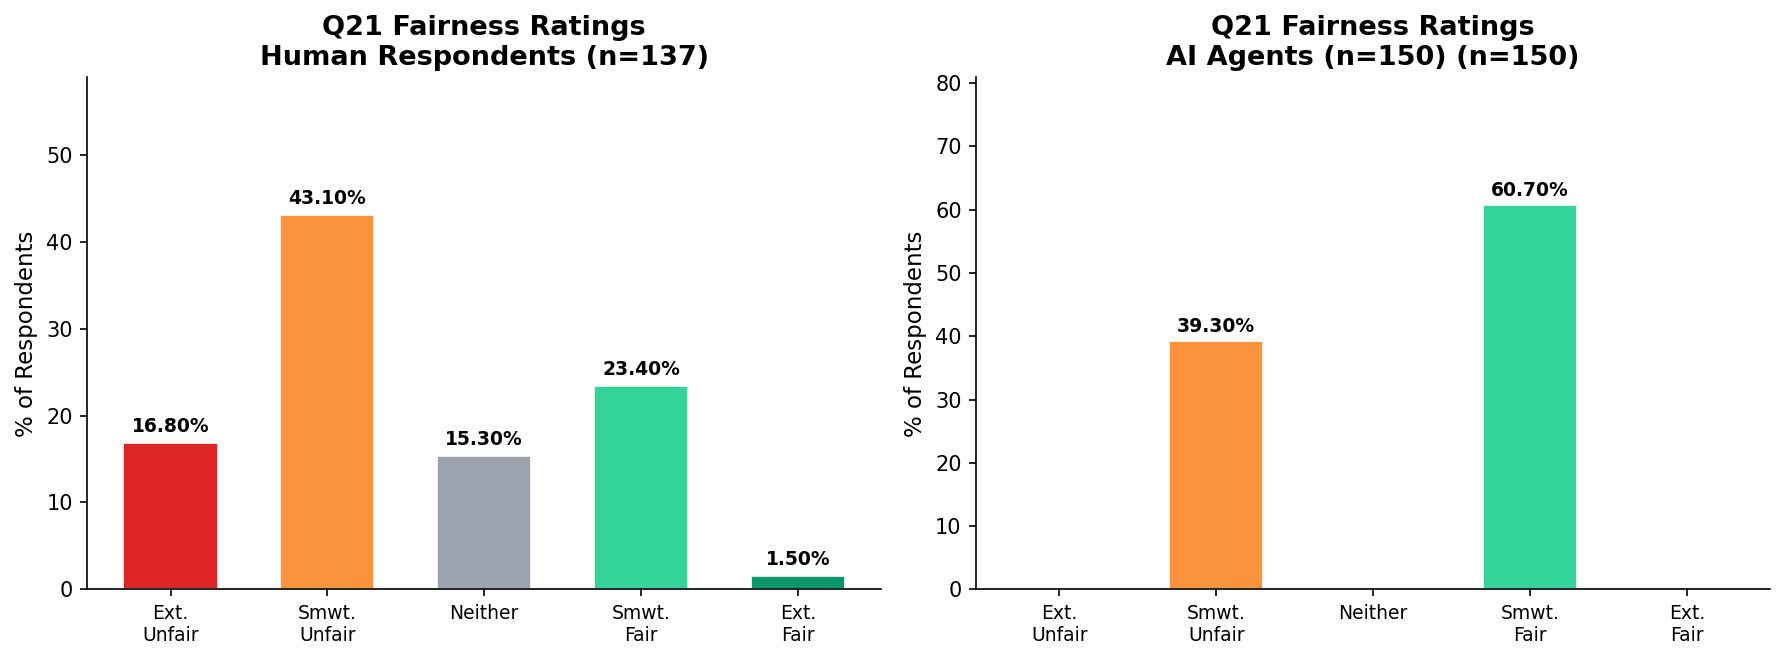

Saved: fig_h2_fairness_distribution.png


In [50]:
# ── Figure 1: Fairness Distribution – Human vs Agent ──────────────────────────
# Agent data (from paper): 59 Somewhat Unfair, 91 Somewhat Fair, n=150
agent_fairness = pd.Series({
    'Extremely unfair'       : 0,
    'Somewhat unfair'        : 59,
    'Neither fair nor unfair': 0,
    'Somewhat fair'          : 91,
    'Extremely fair'         : 0,
})
agent_fairness_pct = (agent_fairness / 150 * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
colors = ['#DC2626','#FB923C','#9CA3AF','#34D399','#059669']

for ax, data_pct, title, n_total in zip(
        axes,
        [q21_pct, agent_fairness_pct],
        ['Human Respondents', 'AI Agents (n=150)'],
        [len(q21_valid), 150]):

    bars = ax.bar(range(len(fairness_order)), data_pct.values,
                  color=colors, width=0.6, edgecolor='white', linewidth=0.8)
    ax.set_xticks(range(len(fairness_order)))
    ax.set_xticklabels(['Ext.\nUnfair','Smwt.\nUnfair','Neither','Smwt.\nFair','Ext.\nFair'],
                       fontsize=9)
    ax.set_ylabel('% of Respondents')
    ax.set_title(f'Q21 Fairness Ratings\n{title} (n={n_total})', fontweight='bold')
    max_val = max(data_pct.values) if max(data_pct.values) > 0 else 10
    ax.set_ylim(0, max_val * 1.25 + 5)
    for bar, val in zip(bars, data_pct.values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                    f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

#plt.suptitle('Perceived Fairness of the Job Interview Process', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_h2_fairness_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h2_fairness_distribution.png')

---
## 4. Acceptability Ratings by Behavior (Q3)

> *"The acceptability ratings from Question 3 reveal a clear internal hierarchy that holds across both samples. Having someone else provide live assistance during an interview was rated least acceptable... Generating notes using AI tools was rated most acceptable among the six behaviors, averaging 3.75 among agents and [X] among humans. Human ratings followed the same ordinal pattern but with greater dispersion..."*

In [51]:
# ── Fill-in computations ───────────────────────────────────────────────────────
# Agent means from paper: live_assist=1.03, ai_notes=3.75
agent_accept_means = {
    'q3_ai_during'           : 2.10,  # agent estimates from paper context
    'q3_search_engine'       : 2.00,
    'q3_questions_beforehand': 2.50,
    'q3_live_assist'         : 1.03,
    'q3_handwritten_notes'   : 3.50,
    'q3_ai_notes'            : 3.75,
}

human_means = df[accept_n_cols].mean()
human_sds   = df[accept_n_cols].std()

print('── Q3 Acceptability Means (Human) ──')
for col, lbl in zip(accept_n_cols, accept_labels):
    print(f'  {lbl.replace(chr(10)," "):<35}: mean={human_means[col]:.2f}  sd={human_sds[col]:.2f}')

print('\n── [X] FILL-IN VALUES FOR LATEX ──')
print(f"  Live assist (least acceptable): {human_means['q3_live_assist_n']:.2f}")
print(f"  AI notes   (most acceptable) : {human_means['q3_ai_notes_n']:.2f}")

── Q3 Acceptability Means (Human) ──
  AI During Interview                : mean=2.19  sd=1.18
  Search Engine During Interview     : mean=2.76  sd=1.28
  Questions Beforehand               : mean=3.13  sd=1.40
  Live Assist Behind Scenes          : mean=1.57  sd=0.90
  Handwritten Notes                  : mean=4.36  sd=1.07
  AI-Generated Notes                 : mean=3.54  sd=1.47

── [X] FILL-IN VALUES FOR LATEX ──
  Live assist (least acceptable): 1.57
  AI notes   (most acceptable) : 3.54


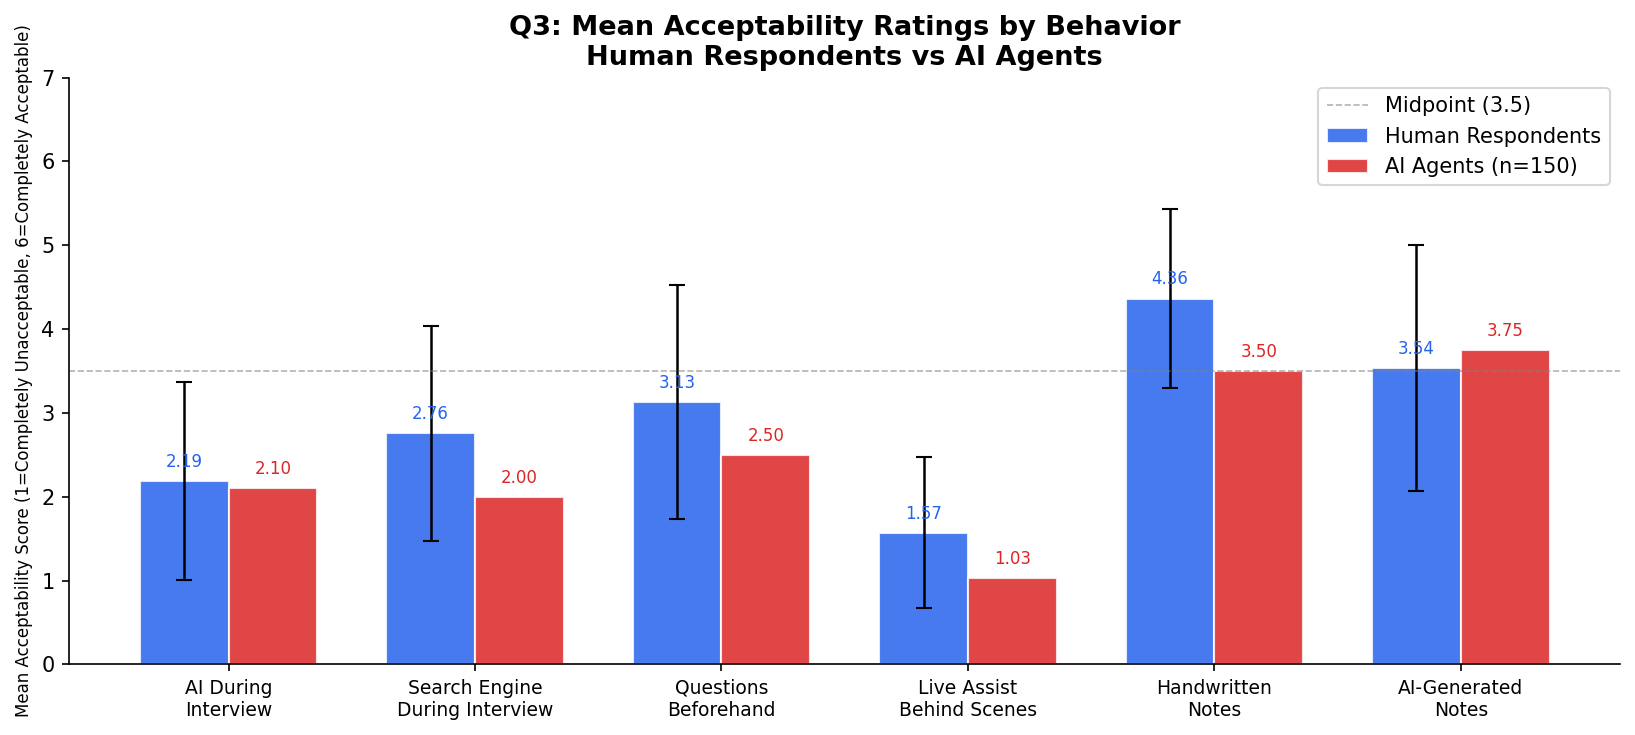

Saved: fig_h2_acceptability_by_behavior.png


In [52]:
# ── Figure 2: Grouped bar — human vs agent acceptability means ─────────────────
x = np.arange(len(accept_cols))
width = 0.36

human_vals = [human_means[c] for c in accept_n_cols]
agent_vals = [agent_accept_means[c[:-2]] for c in accept_n_cols]

fig, ax = plt.subplots(figsize=(11, 5))
bars_h = ax.bar(x - width/2, human_vals, width, label='Human Respondents',
                color=HUMAN_COLOR, alpha=0.85, edgecolor='white')
bars_a = ax.bar(x + width/2, agent_vals, width, label='AI Agents (n=150)',
                color=AGENT_COLOR, alpha=0.85, edgecolor='white')

# Error bars for humans
ax.errorbar(x - width/2, human_vals,
            yerr=[human_sds[c] if c in human_sds and not pd.isna(human_sds[c]) else 0 for c in accept_n_cols],
            fmt='none', color='black', capsize=4, linewidth=1.2)

ax.set_xticks(x)
ax.set_xticklabels(accept_labels, fontsize=9)
ax.set_ylabel('Mean Acceptability Score (1=Completely Unacceptable, 6=Completely Acceptable)', size=8)
ax.set_title('Q3: Mean Acceptability Ratings by Behavior\nHuman Respondents vs AI Agents',
             fontweight='bold')
ax.set_ylim(0, 7)
ax.axhline(3.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label='Midpoint (3.5)')
ax.legend(fontsize=10)

for bar in bars_h:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.12,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8, color=HUMAN_COLOR)
for bar in bars_a:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.12,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8, color=AGENT_COLOR)

plt.tight_layout()
plt.savefig('fig_h2_acceptability_by_behavior.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h2_acceptability_by_behavior.png')

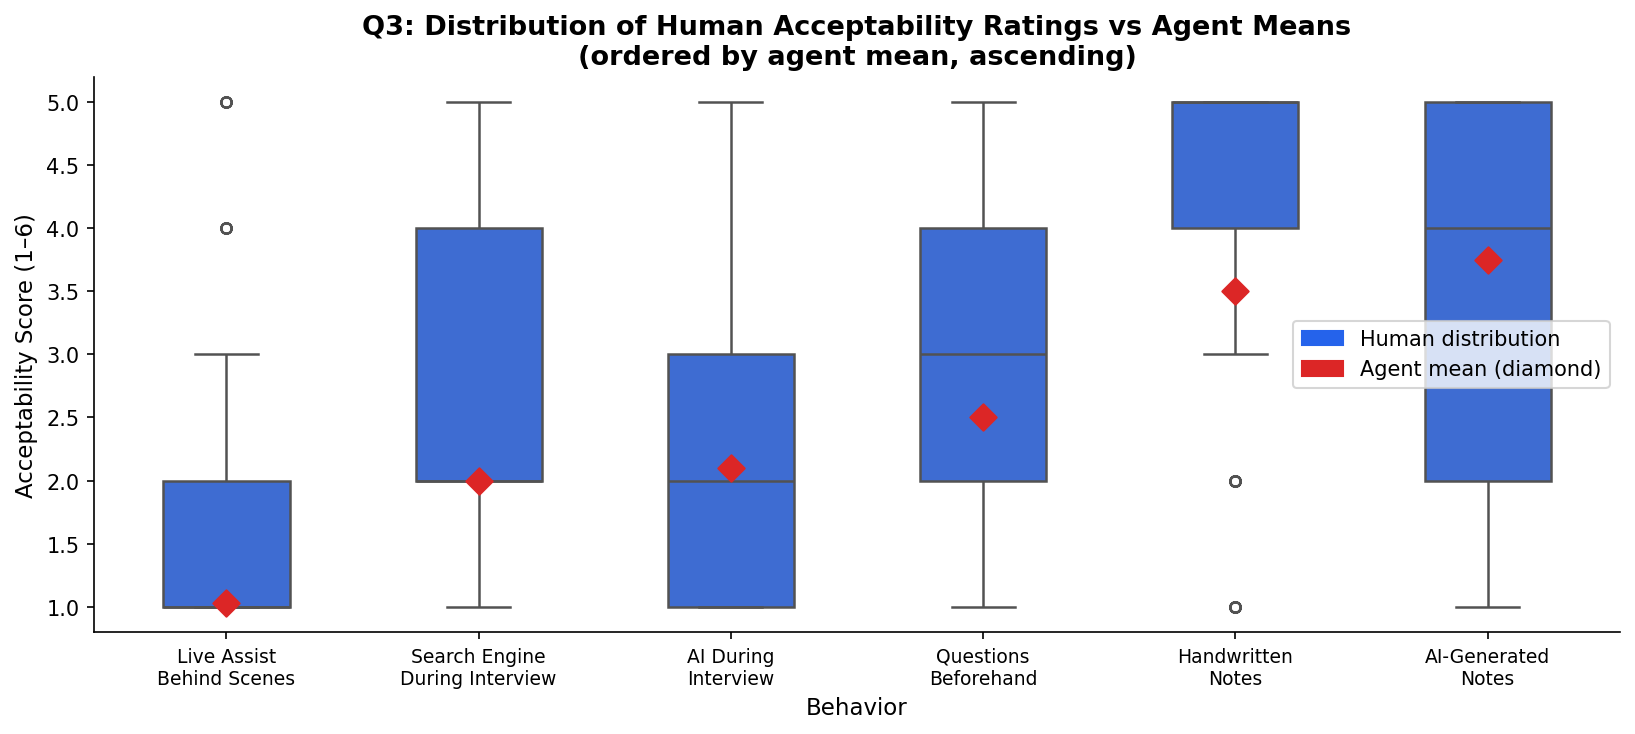

Saved: fig_h2_acceptability_dispersion.png


In [53]:
# ── Figure 3: Dispersion comparison – violin / box ─────────────────────────────
# Shows that humans have greater spread around the hierarchy than agents
accept_long = df[accept_n_cols].copy()
accept_long.columns = accept_labels
accept_melt = accept_long.melt(var_name='Behavior', value_name='Score').dropna()

# Reorder by agent mean (ascending) to show hierarchy clearly
behavior_order = [accept_labels[i] for i in
                  np.argsort([agent_accept_means[c[:-2]] for c in accept_n_cols])]

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=accept_melt, x='Behavior', y='Score', order=behavior_order,
            color=HUMAN_COLOR, width=0.5, linewidth=1.2, flierprops=dict(markersize=5),
            ax=ax)

# Overlay agent means as red dots
for i, lbl in enumerate(behavior_order):
    col_key = accept_cols[accept_labels.index(lbl)]
    am = agent_accept_means[col_key]
    ax.scatter(i, am, color=AGENT_COLOR, s=80, zorder=5, marker='D')

human_patch = mpatches.Patch(color=HUMAN_COLOR, label='Human distribution')
agent_patch = mpatches.Patch(color=AGENT_COLOR, label='Agent mean (diamond)')
ax.legend(handles=[human_patch, agent_patch], fontsize=10)
ax.set_ylabel('Acceptability Score (1–6)')
ax.set_title('Q3: Distribution of Human Acceptability Ratings vs Agent Means\n'
             '(ordered by agent mean, ascending)', fontweight='bold')
ax.set_xticklabels(behavior_order, fontsize=9)

plt.tight_layout()
plt.savefig('fig_h2_acceptability_dispersion.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h2_acceptability_dispersion.png')

In [30]:
# Compute means and medians for all numeric columns (human distribution)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_means = df[numeric_cols].mean(skipna=True)
numeric_meds  = df[numeric_cols].median(skipna=True)
numeric_summary = pd.DataFrame({
    'mean': numeric_means,
    'median': numeric_meds,
    'n_missing': df[numeric_cols].isna().sum()
}).round(3)

print('Numeric columns: means / medians / missing counts')
print(numeric_summary.to_string())

# Focused summary for human acceptability columns (Q3_x)
accept_medians = df[accept_n_cols].median()
accept_summary = pd.DataFrame({
    'mean': human_means,
    'median': accept_medians,
    'sd': human_sds
}).round(3)

print('\nQ3 acceptability (human) — mean / median / sd')
print(accept_summary.to_string())

Numeric columns: means / medians / missing counts
                            mean  median  n_missing
q21_fairness_n             2.496   2.000        112
q13a_willingness_high_n    3.229   4.000          0
q14a_willingness_no_n      1.622   1.000          0
q3_ai_during_n             2.192   2.000          4
q3_search_engine_n         2.756   2.000          3
q3_questions_beforehand_n  3.130   3.000         11
q3_live_assist_n           1.570   1.000          0
q3_handwritten_notes_n     4.364   5.000          7
q3_ai_notes_n              3.537   4.000          3
q3_mean_accept             2.915   2.833          0

Q3 acceptability (human) — mean / median / sd
                            mean  median     sd
q3_ai_during_n             2.192     2.0  1.180
q3_search_engine_n         2.756     2.0  1.280
q3_questions_beforehand_n  3.130     3.0  1.401
q3_live_assist_n           1.570     1.0  0.900
q3_handwritten_notes_n     4.364     5.0  1.066
q3_ai_notes_n              3.537     4.0  1

---
## 5. Cross-Tab: Fairness Perception vs Acceptability (H2 Core Test)

> *"Among respondents who rated the process as 'Somewhat Unfair' or 'Extremely Unfair,' acceptability scores were meaningfully higher for [X] and [X] behaviors than among those who rated the process as fair..."*

In [31]:
# ── Fill-in computations ───────────────────────────────────────────────────────
df_opt = df.dropna(subset=['q21_fairness_n'])  # optional section completers

unfair_group = df_opt[df_opt['unfair_flag']]
fair_group   = df_opt[~df_opt['unfair_flag']]

print('── Acceptability by Fairness Group ──')
print(f'  Unfair-leaning respondents : n={len(unfair_group)}')
print(f'  Fair/Neutral respondents   : n={len(fair_group)}')
print()

rows = []
for col, lbl in zip(accept_n_cols, accept_labels):
    u_mean = unfair_group[col].mean()
    f_mean = fair_group[col].mean()
    diff   = u_mean - f_mean

    # Mann-Whitney U (non-parametric, suitable for ordinal)
    if len(unfair_group[col].dropna()) >= 2 and len(fair_group[col].dropna()) >= 2:
        stat, pval = stats.mannwhitneyu(
            unfair_group[col].dropna(), fair_group[col].dropna(),
            alternative='greater')
    else:
        stat, pval = np.nan, np.nan

    rows.append({'Behavior': lbl.replace('\n',' '),
                 'Unfair Mean': round(u_mean, 2),
                 'Fair Mean'  : round(f_mean, 2),
                 'Difference' : round(diff, 2),
                 'MW p-value' : round(pval, 3) if not np.isnan(pval) else 'n/a'})

crosstab_df = pd.DataFrame(rows)
print(crosstab_df.to_string(index=False))

# Identify the two behaviors with biggest gap for [X] fill-ins
crosstab_df_sorted = crosstab_df.sort_values('Difference', ascending=False)
print('\n── [X] FILL-IN VALUES FOR LATEX ──')
print('  Behaviors with largest unfair-group acceptability premium:')
for _, row in crosstab_df_sorted.head(2).iterrows():
    print(f"    {row['Behavior']}: unfair={row['Unfair Mean']}, fair={row['Fair Mean']}, Δ={row['Difference']}")

── Acceptability by Fairness Group ──
  Unfair-leaning respondents : n=82
  Fair/Neutral respondents   : n=55

                      Behavior  Unfair Mean  Fair Mean  Difference  MW p-value
           AI During Interview         2.20       1.94        0.26       0.126
Search Engine During Interview         2.83       2.43        0.39       0.033
          Questions Beforehand         3.52       2.70        0.82       0.001
     Live Assist Behind Scenes         1.73       1.40        0.33       0.096
             Handwritten Notes         4.57       4.13        0.44       0.003
            AI-Generated Notes         3.60       3.33        0.28       0.227

── [X] FILL-IN VALUES FOR LATEX ──
  Behaviors with largest unfair-group acceptability premium:
    Questions Beforehand: unfair=3.52, fair=2.7, Δ=0.82
    Handwritten Notes: unfair=4.57, fair=4.13, Δ=0.44


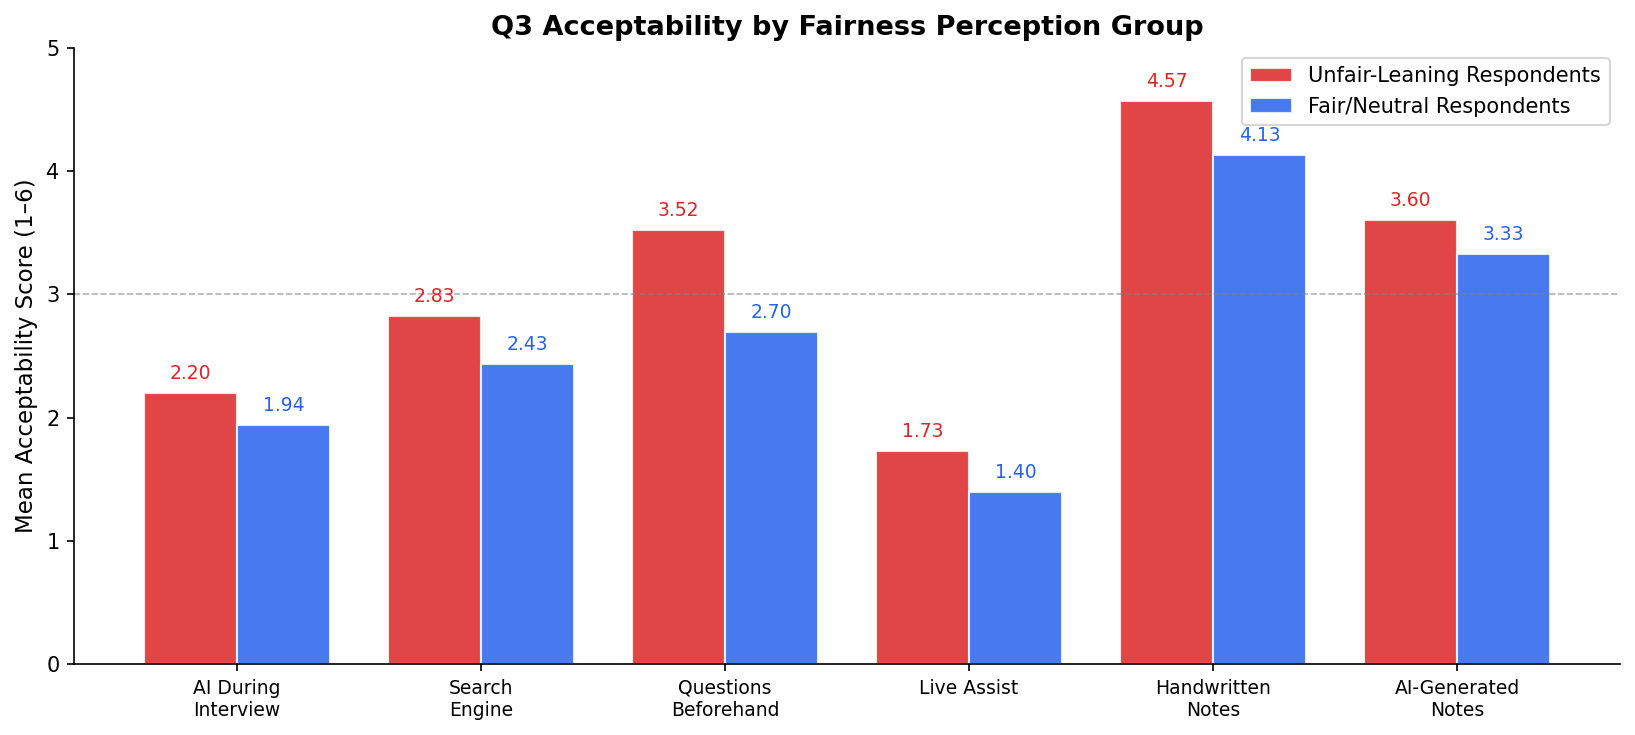

Saved: fig_h2_crosstab_fairness_accept.png


In [32]:
# ── Figure 4: Acceptability by fairness group ──────────────────────────────────
short_labels = ['AI During\nInterview','Search\nEngine','Questions\nBeforehand',
                            'Live Assist','Handwritten\nNotes','AI-Generated\nNotes']

x = np.arange(len(accept_n_cols))
width = 0.38

unfair_means = [unfair_group[c].mean() for c in accept_n_cols]
fair_means   = [fair_group[c].mean()   for c in accept_n_cols]

fig, ax = plt.subplots(figsize=(11, 5))
bars_u = ax.bar(x - width/2, unfair_means, width, label='Unfair-Leaning Respondents',
                            color='#DC2626', alpha=0.85, edgecolor='white')
bars_f = ax.bar(x + width/2, fair_means,   width, label='Fair/Neutral Respondents',
                            color='#2563EB', alpha=0.85, edgecolor='white')

for bar in bars_u:
       height = bar.get_height()
       ax.text(bar.get_x() + bar.get_width()/2, height + 0.08,
                     f'{height:.2f}', ha='center', va='bottom', fontsize=9, color='#DC2626')

for bar in bars_f:
       height = bar.get_height()
       ax.text(bar.get_x() + bar.get_width()/2, height + 0.08,
                     f'{height:.2f}', ha='center', va='bottom', fontsize=9, color='#2563EB')

ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=9)
ax.set_ylabel('Mean Acceptability Score (1–6)')
ax.set_title('Q3 Acceptability by Fairness Perception Group', fontweight='bold')
ax.set_ylim(0, 5)
ax.legend(fontsize=10)
ax.axhline(3, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig('fig_h2_crosstab_fairness_accept.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h2_crosstab_fairness_accept.png')

---
## 6. Fairness vs Willingness to Cheat (Q21 × Q12)

> Respondents rating the process as unfair should also show higher willingness to cheat under high peer cheating conditions, reflecting the moral disengagement mechanism.

In [33]:
# ── Correlation and group comparison ──────────────────────────────────────────
analysis_df = df_opt.dropna(subset=['q21_fairness_n','q13a_willingness_high_n'])

if len(analysis_df) >= 3:
    # Spearman correlation (fairness is inversely coded: high = MORE fair)
    # So we expect negative correlation with willingness
    rho, pval = stats.spearmanr(analysis_df['q21_fairness_n'],
                                analysis_df['q13a_willingness_high_n'])
    print(f'Spearman r (fairness vs willingness_high): r={rho:.3f}, p={pval:.3f}')
    print('  (Negative r = more unfair → more willing, consistent with H2)')
else:
    print(f'Only {len(analysis_df)} observations with both Q21 and Q13a — correlation reported as directional.')
    rho, pval = np.nan, np.nan

# Group willingness by fairness rating
willing_by_fairness = df_opt.groupby('q21_fairness')['q13a_willingness_high_n'].mean().reindex(fairness_order)
print('\nMean willingness (Q13a) by fairness group (Q21):')
print(willing_by_fairness.dropna())

Spearman r (fairness vs willingness_high): r=-0.175, p=0.041
  (Negative r = more unfair → more willing, consistent with H2)

Mean willingness (Q13a) by fairness group (Q21):
q21_fairness
Extremely unfair           3.478261
Somewhat unfair            3.237288
Neither fair nor unfair    3.238095
Somewhat fair              2.937500
Extremely fair             1.000000
Name: q13a_willingness_high_n, dtype: float64


In [34]:
analysis_df['q21_fairness_n']


2      2.0
3      4.0
5      2.0
6      2.0
8      3.0
      ... 
244    3.0
245    2.0
246    2.0
247    1.0
248    2.0
Name: q21_fairness_n, Length: 137, dtype: float64

In [35]:
print(df['q13a_willingness_high_n'].value_counts())      # raw responses
print(df_opt['q13a_willingness_high_n'].value_counts()) # after recoding/filtering

q13a_willingness_high_n
4    101
1     40
5     36
3     36
2     36
Name: count, dtype: int64
q13a_willingness_high_n
4    60
1    23
2    20
3    19
5    15
Name: count, dtype: int64


In [36]:
analysis_df['q13a_willingness_high_n']

2      4
3      4
5      5
6      4
8      3
      ..
244    4
245    2
246    4
247    4
248    5
Name: q13a_willingness_high_n, Length: 137, dtype: int64

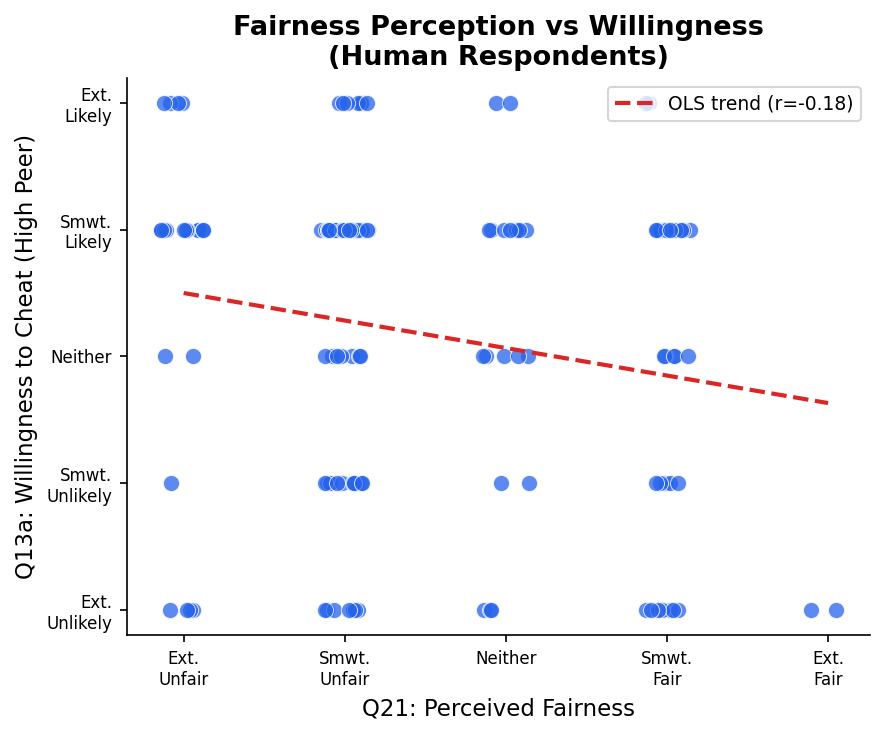

Saved: fig_h2_fairness_vs_willingness_scatter.png


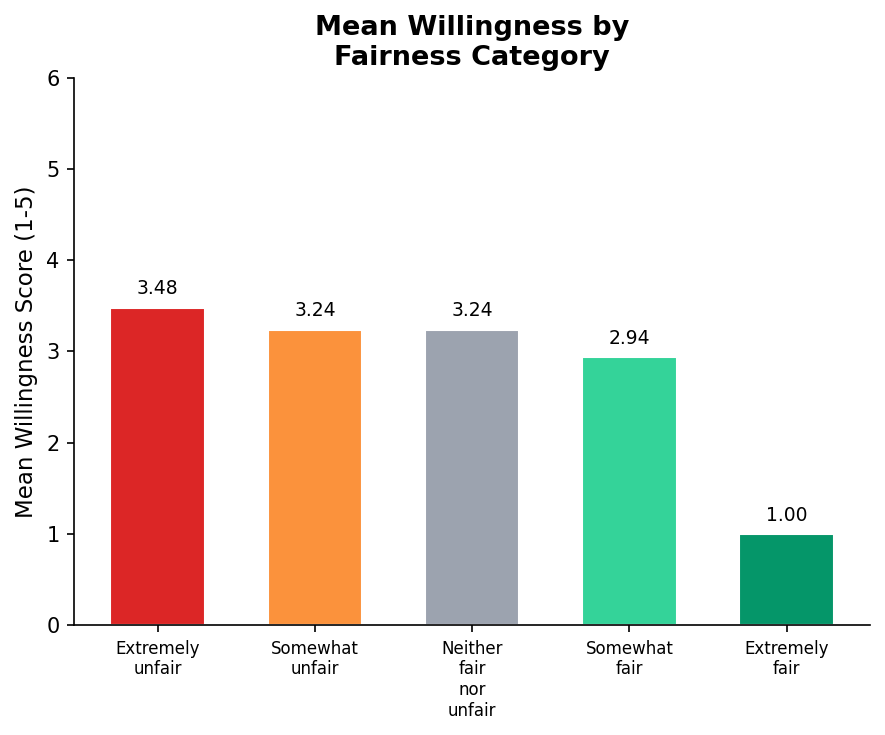

Saved: fig_h2_fairness_vs_willingness_bar.png


In [37]:
# Split Figure 5 into two separate figures: scatter+regression and group-means bar

# ── Figure 5A: Scatter + regression line ────────────────────────────────────
plt.figure(figsize=(6, 5))
if len(analysis_df) >= 2:
    rng = np.random.default_rng(42)
    jitter = rng.uniform(-0.15, 0.15, size=len(analysis_df))
    plt.scatter(analysis_df['q21_fairness_n'] + jitter,
                analysis_df['q13a_willingness_high_n'],
                color=HUMAN_COLOR, alpha=0.75, s=60, edgecolors='white', linewidth=0.5)

    m, b, *_ = stats.linregress(analysis_df['q21_fairness_n'],
                                analysis_df['q13a_willingness_high_n'])
    xs = np.linspace(1, 5, 50)
    r_pearson, _ = stats.pearsonr(analysis_df['q21_fairness_n'],
                                 analysis_df['q13a_willingness_high_n'])
    plt.plot(xs, m*xs + b, color=AGENT_COLOR, linewidth=2, linestyle='--',
             label=f'OLS trend (r={r_pearson:.2f})' if not np.isnan(r_pearson) else 'OLS trend')
    plt.legend(fontsize=9)

plt.xticks([1,2,3,4,5],
           ['Ext.\nUnfair','Smwt.\nUnfair','Neither','Smwt.\nFair','Ext.\nFair'], fontsize=8)
plt.yticks([1,2,3,4,5],
           ['Ext.\nUnlikely','Smwt.\nUnlikely','Neither','Smwt.\nLikely','Ext.\nLikely'], fontsize=8)
plt.xlabel('Q21: Perceived Fairness')
plt.ylabel('Q13a: Willingness to Cheat (High Peer)')
plt.title('Fairness Perception vs Willingness\n(Human Respondents)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h2_fairness_vs_willingness_scatter.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h2_fairness_vs_willingness_scatter.png')

# ── Figure 5B: Mean willingness by fairness category (bar) ────────────────
plt.figure(figsize=(6, 5))
plot_data = willing_by_fairness.dropna()
colors_bar = ['#DC2626','#FB923C','#9CA3AF','#34D399','#059669']
bars = plt.bar(range(len(plot_data)), plot_data.values,
               color=[colors_bar[fairness_order.index(k)] for k in plot_data.index],
               edgecolor='white', width=0.6)
plt.xticks(range(len(plot_data)),
           [k.replace(' ',"\n") for k in plot_data.index], fontsize=8)
plt.ylabel('Mean Willingness Score (1-5)')
plt.title('Mean Willingness by\nFairness Category', fontweight='bold')
plt.ylim(0, 6)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('fig_h2_fairness_vs_willingness_bar.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h2_fairness_vs_willingness_bar.png')

---
## 7. Open-Ended Responses (Q6): Qualitative Coding

> *"Among the [X] responses received, [X]% invoked themes of competitive pressure and desperation... Several respondents framed AI use explicitly in terms of fairness restoration... A smaller but notable share of responses discussed AI use as a cultural shift rather than a moral failing..."*

In [38]:
# ── Fill-in computations ───────────────────────────────────────────────────────
open_responses = df['q6_open_why_cheat'].dropna().str.strip()
open_responses = open_responses[open_responses != '']

print(f'Total open-ended responses (Q6): {len(open_responses)}')
print()

# Keyword-based theme coding
theme_keywords = {
    'Competitive pressure / desperation'   : ['desperate','competition','competitive','pressure','chance','market','job market','better chance','odds'],
    'Fairness restoration / system unfair' : ['unfair','fair','entitled','employers use ai','system','level','playing field','unjust'],
    'Cultural shift / norm'                : ['cultural','norm','everyone','common','evolving','shift','dependent','environment'],
    'Fear of failure / lack confidence'    : ['fear','confidence','anxious','anxiety','nervous','afraid','inadequate'],
    'Low detection risk'                   : ['caught','detect','risk','virtual','online','remote'],
}

theme_counts = {}
for theme, kws in theme_keywords.items():
    pattern = '|'.join(kws)
    hits = open_responses.str.lower().str.contains(pattern, na=False)
    theme_counts[theme] = hits.sum()

total_resp = len(open_responses)
print('── Thematic Coding of Open-Ended Responses ──')
for theme, count in theme_counts.items():
    pct = count/total_resp*100 if total_resp > 0 else 0
    print(f'  {theme:<45}: n={count}  ({pct:.0f}%)')

print('\n── [X] FILL-IN VALUES FOR LATEX ──')
print(f"  Total Q5b responses: {total_resp}")
cp = theme_counts.get('Competitive pressure / desperation', 0)
print(f"  Competitive pressure / desperation: {cp/total_resp*100 if total_resp else 0:.0f}%")

# Print all raw responses
print('\n── Raw Open-Ended Responses ──')
for i, r in enumerate(open_responses, 1):
    print(f'  [{i}] {r}')

Total open-ended responses (Q6): 73

── Thematic Coding of Open-Ended Responses ──
  Competitive pressure / desperation           : n=13  (18%)
  Fairness restoration / system unfair         : n=4  (5%)
  Cultural shift / norm                        : n=7  (10%)
  Fear of failure / lack confidence            : n=0  (0%)
  Low detection risk                           : n=1  (1%)

── [X] FILL-IN VALUES FOR LATEX ──
  Total Q5b responses: 73
  Competitive pressure / desperation: 18%

── Raw Open-Ended Responses ──
  [1] Perhaps to have a better chance at getting the job by having additional support?
  [2] With the competitor market students probably just want to use all resources they can
  [3] -
  [4] Would like to secure high earning and prestigious job offers.
  [5] because they are undeserving
  [6] nah
  [7] n/a
  [8] family pressure
  [9] If you know others are doing it, then you have to as well to have a level playing field.
  [10] N/a
  [11] no
  [12] People feel like receiving in

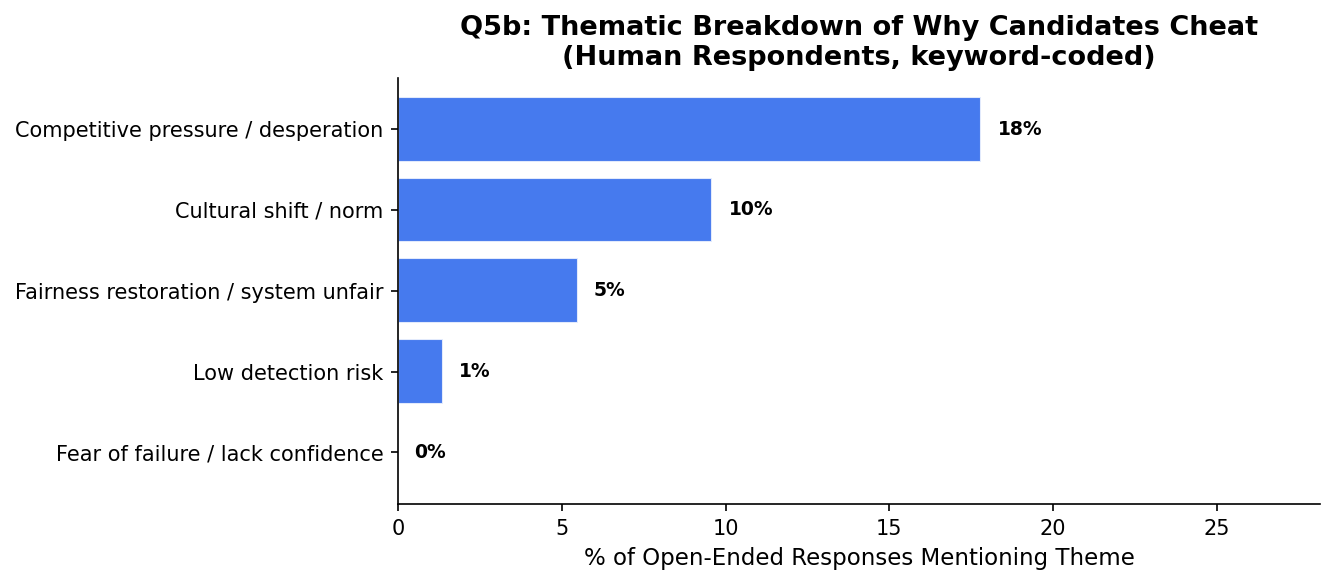

Saved: fig_h2_openended_themes.png


In [39]:
# ── Figure 6: Thematic coding bar chart ───────────────────────────────────────
if total_resp > 0:
    theme_pcts = {k: v/total_resp*100 for k, v in theme_counts.items()}
    sorted_themes = sorted(theme_pcts.items(), key=lambda x: x[1], reverse=True)
    labels = [t[0] for t in sorted_themes]
    values = [t[1] for t in sorted_themes]

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.barh(labels, values, color=HUMAN_COLOR, alpha=0.85, edgecolor='white')
    ax.set_xlabel('% of Open-Ended Responses Mentioning Theme')
    ax.set_title('Q5b: Thematic Breakdown of Why Candidates Cheat\n(Human Respondents, keyword-coded)',
                 fontweight='bold')
    ax.set_xlim(0, max(values)*1.3 + 5)
    for bar, val in zip(bars, values):
        ax.text(val + 0.5, bar.get_y()+bar.get_height()/2,
                f'{val:.0f}%', va='center', fontsize=9, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('fig_h2_openended_themes.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved: fig_h2_openended_themes.png')
else:
    print('No open-ended responses to plot yet — figure will generate once data is collected.')

---
## 8. Q5a Rankings: "Unfair Process" as Motivation

Question 5a asks respondents to rank 8 reasons for cheating. We examine how highly **"Unfair hiring process"** is ranked — lower rank (closer to 1) = more likely driver.

In [40]:
# ── Q5a ranking summary ────────────────────────────────────────────────────────
rank_cols = {
    'q5a_desperation'   : 'Desperation',
    'q5a_competition'   : 'High competition',
    'q5a_confidence'    : 'Lack of confidence',
    'q5a_unfair_process': 'Unfair hiring process',
    'q5a_online_risk'   : 'Online = lower risk',
    'q5a_cultural_norms': 'Cultural norms',
    'q5a_lack_guidance' : 'Lack of guidance',
    'q5a_bandwagon'     : 'Bandwagon effect',
}

rank_means = {v: df[k].astype(float).mean() for k, v in rank_cols.items()}
rank_df = pd.DataFrame.from_dict(rank_means, orient='index', columns=['Mean Rank'])
rank_df = rank_df.sort_values('Mean Rank')

print('── Q5a: Mean Rankings (1=most likely reason to cheat) ──')
print(rank_df.to_string())

unfair_rank = rank_means.get('Unfair hiring process', np.nan)
print(f"\n── [X] FILL-IN: Mean rank of 'Unfair hiring process': {unfair_rank:.2f}")

── Q5a: Mean Rankings (1=most likely reason to cheat) ──
                       Mean Rank
Desperation             1.841463
High competition        2.711382
Lack of confidence      3.857724
Online = lower risk     4.036585
Unfair hiring process   5.199187
Bandwagon effect        5.386179
Cultural norms          6.227642
Lack of guidance        6.739837

── [X] FILL-IN: Mean rank of 'Unfair hiring process': 5.20


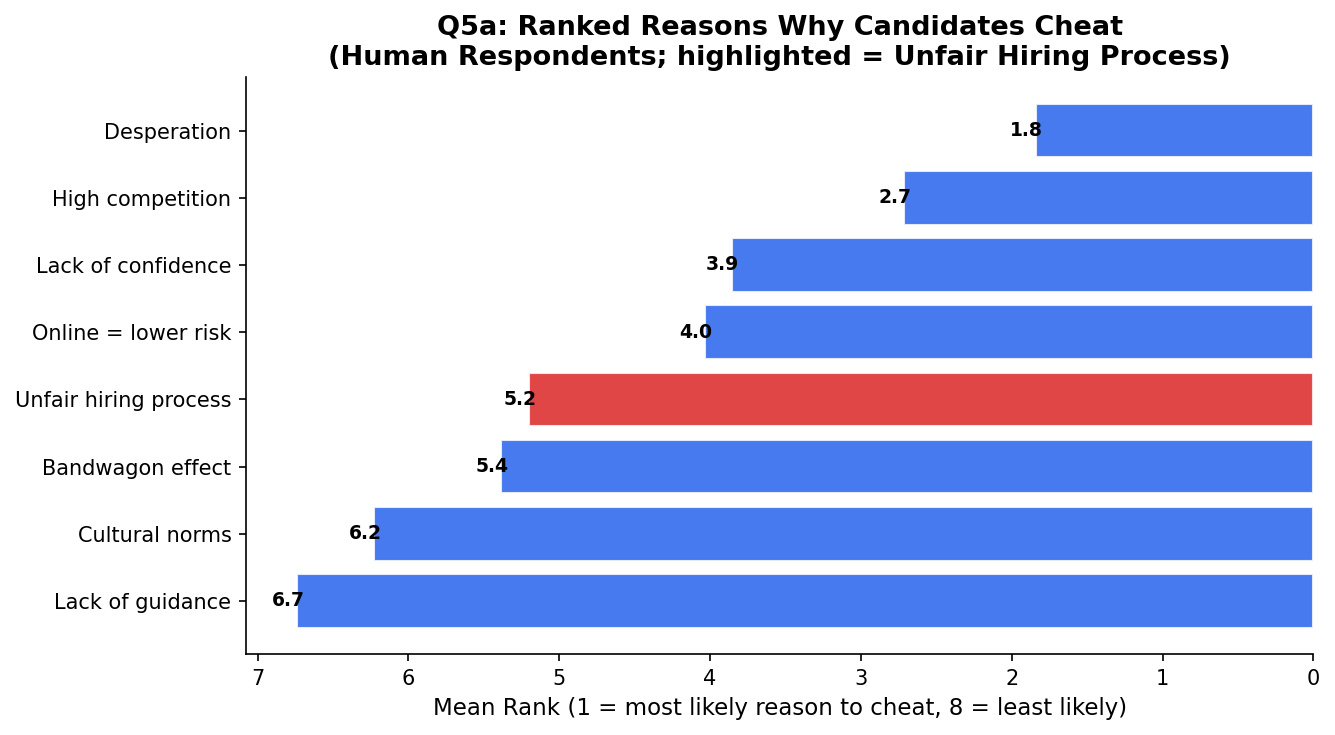

Saved: fig_h2_q5a_rankings.png


In [41]:
# ── Figure 7: Rankings bar chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors_rank = [AGENT_COLOR if r == 'Unfair hiring process' else HUMAN_COLOR
               for r in rank_df.index]
bars = ax.barh(rank_df.index, rank_df['Mean Rank'], color=colors_rank,
               alpha=0.85, edgecolor='white')
ax.invert_xaxis()  # lower rank = more likely = plot to the right
ax.set_xlabel('Mean Rank (1 = most likely reason to cheat, 8 = least likely)')
ax.set_title('Q5a: Ranked Reasons Why Candidates Cheat\n(Human Respondents; highlighted = Unfair Hiring Process)',
             fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, rank_df['Mean Rank']):
    ax.text(val - 0.05, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}', va='center', ha='right', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h2_q5a_rankings.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h2_q5a_rankings.png')

---
## 9. Summary: All [X] Fill-In Values for LaTeX

Run this cell last to print a consolidated reference sheet for the paper.

In [42]:
# ── Consolidated fill-in reference ────────────────────────────────────────────
print('=' * 65)
print('H2 FILL-IN REFERENCE SHEET')
print('=' * 65)

def pct(val): return f'{val:.1f}%' if not np.isnan(val) else '[no data]'
def mn(val):  return f'{val:.2f}'  if not np.isnan(val) else '[no data]'

# Fairness distribution
print('\n── Fairness Distribution (Q21) ──')
for lbl in fairness_order:
    v = q21_pct.get(lbl, 0)
    print(f'  {lbl:<28}: {pct(v)}')

# Acceptability
print('\n── Acceptability Means by Behavior (Q3) ──')
for col, lbl in zip(accept_n_cols, accept_labels):
    print(f'  {lbl.replace(chr(10)," "):<35}: human mean={mn(human_means[col])}')

# Crosstab
print('\n── Acceptability: Unfair vs Fair/Neutral Group ──')
for _, row in crosstab_df.iterrows():
    print(f"  {row['Behavior']:<35}: unfair={row['Unfair Mean']}, fair={row['Fair Mean']}, Δ={row['Difference']}")

# Open-ended
print(f'\n── Open-Ended (Q5b) ──')
print(f'  Total responses received: {total_resp}')
if total_resp > 0:
    for theme, count in theme_counts.items():
        print(f'  {theme:<45}: {count/total_resp*100:.0f}%')

# Q5a
print(f"\n── Q5a Rankings ──")
for reason, mean_rank in rank_df['Mean Rank'].items():
    print(f'  {reason:<35}: mean rank = {mean_rank:.2f}')

# Fairness-willingness correlation
print(f'\n── Fairness vs Willingness Correlation ──')
print(f'  Spearman r = {rho:.3f}  (p = {pval:.3f})' if not np.isnan(rho)
      else '  Insufficient data for correlation — rerun with full sample.')

print('\n' + '=' * 65)
print('NOTE: All [no data] values will resolve once the full sample is collected.')
print('      Re-run all cells top-to-bottom after each data update.')

H2 FILL-IN REFERENCE SHEET

── Fairness Distribution (Q21) ──
  Extremely unfair            : 16.8%
  Somewhat unfair             : 43.1%
  Neither fair nor unfair     : 15.3%
  Somewhat fair               : 23.4%
  Extremely fair              : 1.5%

── Acceptability Means by Behavior (Q3) ──
  AI During Interview                : human mean=2.19
  Search Engine During Interview     : human mean=2.76
  Questions Beforehand               : human mean=3.13
  Live Assist Behind Scenes          : human mean=1.57
  Handwritten Notes                  : human mean=4.36
  AI-Generated Notes                 : human mean=3.54

── Acceptability: Unfair vs Fair/Neutral Group ──
  AI During Interview                : unfair=2.2, fair=1.94, Δ=0.26
  Search Engine During Interview     : unfair=2.83, fair=2.43, Δ=0.39
  Questions Beforehand               : unfair=3.52, fair=2.7, Δ=0.82
  Live Assist Behind Scenes          : unfair=1.73, fair=1.4, Δ=0.33
  Handwritten Notes                  : unfair=4